In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

from multiprocessing import Pool
from joblib import Parallel, delayed

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [2]:
npix = 2
yy_s, yy_e = 2002, 2023
NEIBHR = 2*npix+1

In [3]:
# product, time_reso = 'IMERG', '3h'
product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [4]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [5]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_100321/726573604.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


In [6]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','uncorrected')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [7]:
if product == 'IMERG':
    filename = 'ITALY_DOWN_IMERG_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

elif product == 'CMORPH':
    filename = 'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

elif product == 'MSWEP':
    filename = 'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

elif product == 'ERA5':
    filename = 'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

elif product == 'GSMaP':
    filename = 'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

elif product == 'CHIRPS':
    filename = 'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

else:
    sys.exit('Product not found')

In [8]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

Tr = DATA.Tr.values
Fi = 1 -1/Tr

lon2d, lat2d = np.meshgrid(lons, lats)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

indices_lat, indices_lon = np.where(mask_study)

NYs = DATA.NYs.values
CYs = DATA.CYs.values
WYs = DATA.WYs.values

BETA = DATA.BETA.values
GAMMA = DATA.GAMMA.values

Mev_s = DATA.Mev_s.values
Mev_d = DATA.Mev_d.values

Product: CMORPH


In [9]:
if product == 'IMERG':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_IMERG_3h_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

elif product == 'CMORPH':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_CMORPH_3h_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

elif product == 'MSWEP':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_MSWEP_3h_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

elif product == 'ERA5':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_ERA5_3h_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

elif product == 'GSMaP':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_GSMaP_3h_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

elif product == 'CHIRPS':
    dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_CHIRPS_1dy_2002_2023_npix_2.nc')
    DATA_BETA = xr.open_dataset(dir_input)
    DATA_BETA = DATA_BETA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
    BETANEW = DATA_BETA.BETA.values

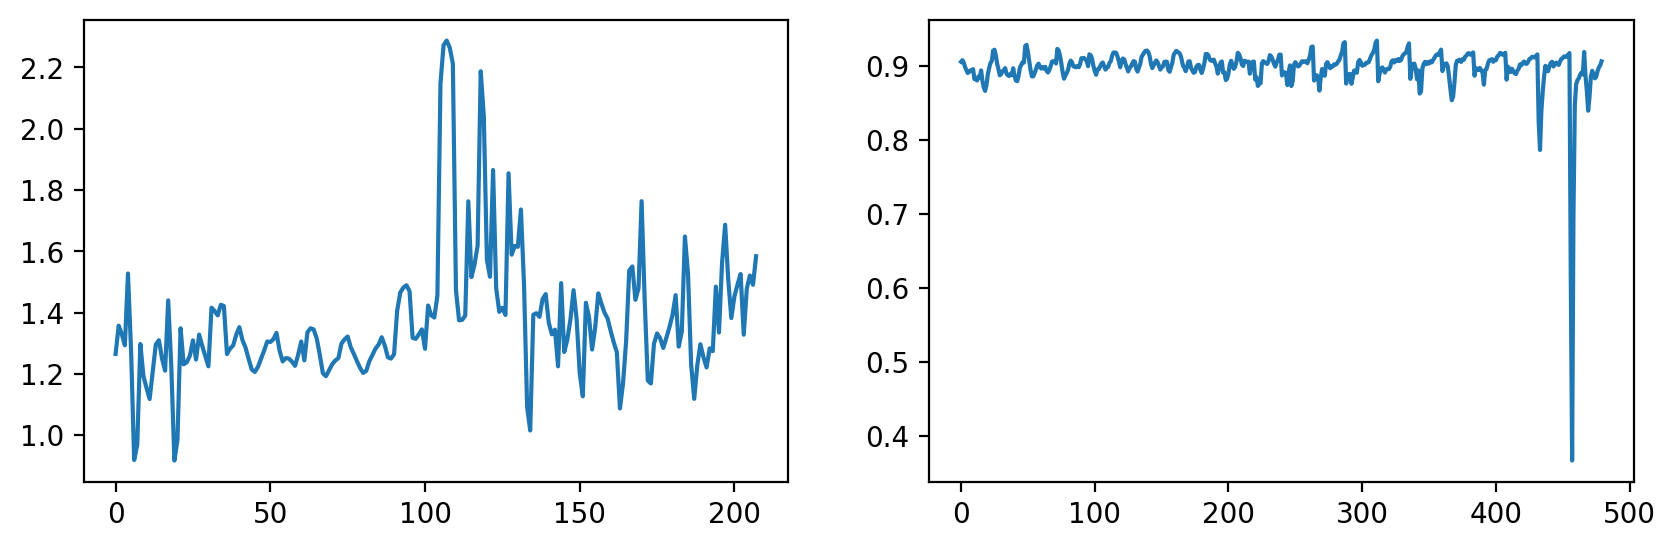

In [10]:
fig = plt.figure(figsize=(10, 3), dpi=200)
gs = gridspec.GridSpec(1, 2)

ax1 = plt.subplot(gs[0, 0])
ax1.plot(BETA[np.isnan(BETA)==False])

ax1 = plt.subplot(gs[0, 1])
plt.plot(GAMMA[np.isnan(GAMMA)==False])

In [11]:
posy, posx = 0, 15
NYs_pos = NYs[:, posy, posx]
CYs_pos = CYs[:, posy, posx]
WYs_pos = WYs[:, posy, posx]

BETA_pos = BETA[posy, posx]
GAMMA_pos = GAMMA[posy, posx]

Mev_s_pos = Mev_s[:,posy, posx]
Mev_d_pos = Mev_d[:,posy, posx]

BETA_new_pos = BETANEW[posy, posx]

print(f'BETA  : {BETA_pos}')
print(f'GAMMA : {GAMMA_pos}')
print()
print(f'BETAN : {BETA_new_pos}')

BETA  : 1.1925116450198774
GAMMA : 0.8937116265296936

BETAN : 1.1925116450198774


In [12]:
Original = ART_downscale.down_wei_beta_alpha_update_v2(NYs_pos, CYs_pos, WYs_pos, BETA_pos, GAMMA_pos)
NYs_down = Original[0]
CYs_down = Original[1]
WYs_down = Original[2]

Manual = ART_downscale.down_wei_beta_alpha_update_v2(NYs_pos, CYs_pos, WYs_pos, BETA_new_pos, GAMMA_pos)
NYs_manual = Manual[0]
CYs_manual = Manual[1]
WYs_manual = Manual[2]

In [13]:
Mev_d_man, _ = ART_downscale.mev_quant_update(Fi, np.nanmean(NYs_manual), NYs_manual, CYs_manual, WYs_manual)

In [14]:
Mev_d_man

array([ 78.72615501,  93.68311109, 108.81383867, 129.64035986,
       146.22530636, 163.62207809])

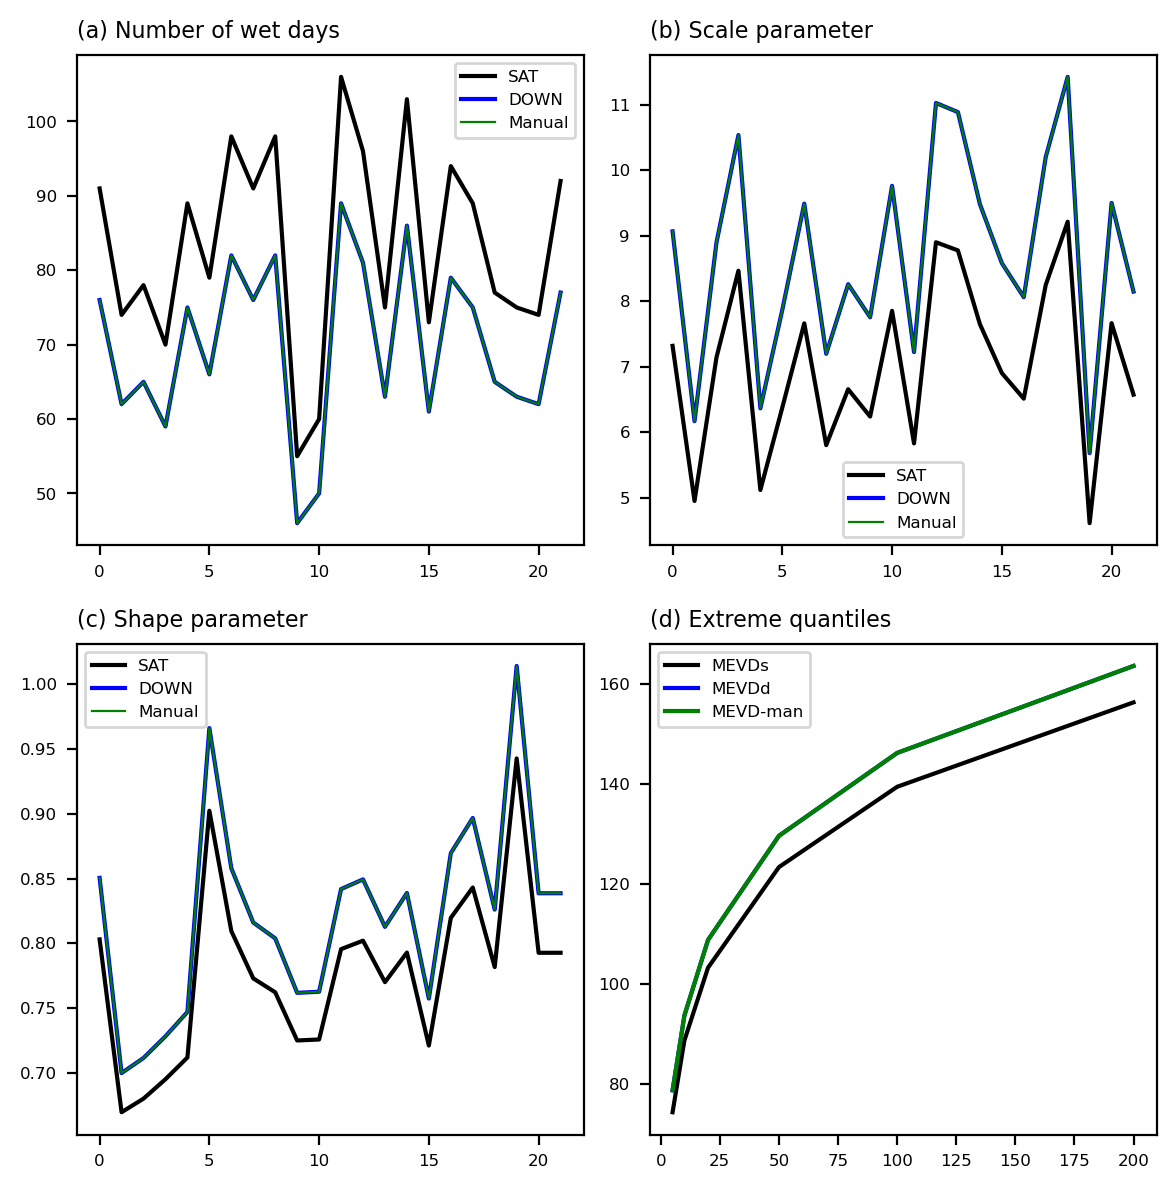

In [15]:
fig = plt.figure(figsize=(6, 6), dpi=200)
gs = gridspec.GridSpec(2, 2)

ax1 = plt.subplot(gs[0, 0])
ax1.plot(NYs_pos[np.isnan(NYs_pos)==False], c='k', label='SAT')
ax1.plot(NYs_down[np.isnan(NYs_down)==False], c='b', label='DOWN')
ax1.plot(NYs_manual[np.isnan(NYs_manual)==False], c='g', linewidth=0.8, label='Manual')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.set_title('(a) Number of wet days', fontsize=8, loc='left')
ax1.legend(fontsize=6)

ax1 = plt.subplot(gs[0, 1])
ax1.plot(CYs_pos[np.isnan(CYs_pos)==False], c='k', label='SAT')
ax1.plot(CYs_down[np.isnan(CYs_down)==False], c='b', label='DOWN')
ax1.plot(CYs_manual[np.isnan(CYs_manual)==False], c='g', linewidth=0.8, label='Manual')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.set_title('(b) Scale parameter', fontsize=8, loc='left')
ax1.legend(fontsize=6)

ax1 = plt.subplot(gs[1, 0])
ax1.plot(WYs_pos[np.isnan(WYs_pos)==False], c='k', label='SAT')
ax1.plot(WYs_down[np.isnan(WYs_down)==False], c='b', label='DOWN')
ax1.plot(WYs_manual[np.isnan(WYs_manual)==False], c='g', linewidth=0.8, label='Manual')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.set_title('(c) Shape parameter', fontsize=8, loc='left')
ax1.legend(fontsize=6)

ax1 = plt.subplot(gs[1, 1])
ax1.plot(Tr, Mev_s_pos, c='k', label='MEVDs')
ax1.plot(Tr, Mev_d_pos, c='b', label='MEVDd')
ax1.plot(Tr, Mev_d_man, c='g', label='MEVD-man')

ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.set_title('(d) Extreme quantiles', fontsize=8, loc='left')
ax1.legend(fontsize=6)

plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.13, hspace=0.2)

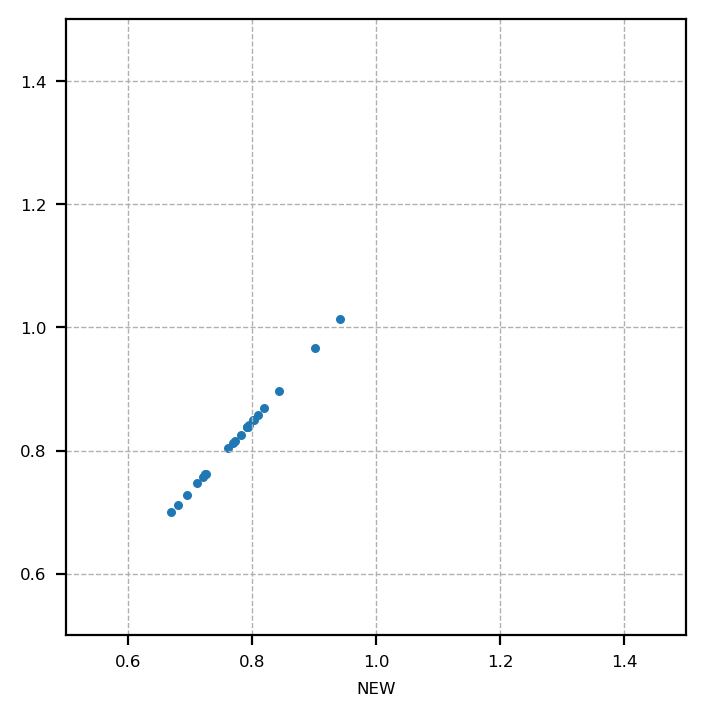

In [16]:
fig = plt.figure(figsize=(4, 4), dpi=200)
gs = gridspec.GridSpec(1, 1)

ax1 = plt.subplot(gs[0, 0])
ax1.scatter(WYs_pos[np.isnan(WYs_pos)==False],WYs_manual[np.isnan(WYs_manual)==False],s=5)
ax1.set_xlim(0.5,1.5)
ax1.set_ylim(0.5,1.5)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.set_xlabel('OLD',fontsize=6)
ax1.set_xlabel('NEW',fontsize=6)
ax1.tick_params(axis='both', which='major', labelsize=6)

In [17]:
sys.exit()

SystemExit: 

/home/arturo/anaconda3/envs/AXE/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Plot all BETA and GAMMA for each product

In [27]:
npix = 2
yy_s, yy_e = 2002, 2023
NEIBHR = 2*npix+1

In [28]:
GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_100321/2121281633.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


In [29]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','uncorrected','BEST')

In [51]:
filename = 'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)
BETA_IM = DATA.BETA.where(mask_study).values
GAMMA_IM = DATA.GAMMA.where(mask_study).values

filename = 'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)
BETA_CM = DATA.BETA.where(mask_study).values
GAMMA_CM = DATA.GAMMA.where(mask_study).values

filename = 'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
BETA_MS = DATA.BETA.values
GAMMA_MS = DATA.GAMMA.values

filename = 'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)
BETA_ER = DATA.BETA.where(mask_study).values
GAMMA_ER = DATA.GAMMA.where(mask_study).values

filename = 'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)
BETA_GS = DATA.BETA.where(mask_study).values
GAMMA_GS = DATA.GAMMA.where(mask_study).values

filename = 'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
dir_input = os.path.join(dir_base,filename)
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)
BETA_CH = DATA.BETA.where(mask_study).values
GAMMA_CH = DATA.GAMMA.where(mask_study).values

In [53]:
dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_IMERG_3h_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_IM_NEW = DATA_BETA.BETA.values

dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_CMORPH_3h_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_CM_NEW = DATA_BETA.BETA.values

dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_MSWEP_3h_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_MS_NEW = DATA_BETA.BETA.values

dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_ERA5_3h_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_ER_NEW = DATA_BETA.BETA.values

dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_GSMaP_3h_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_GS_NEW = DATA_BETA.BETA.values

dir_input = ('/media/arturo/T9/Data/Italy/Satellite/2_MEV/beta/ITALY_Beta_CHIRPS_1dy_2002_2023_npix_2.nc')
DATA_BETA = xr.open_dataset(dir_input)
BETA_CH_NEW = DATA_BETA.BETA.values

In [63]:
DATA = xr.open_dataset(dir_input)
# DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)
lon2d, lat2d = np.meshgrid(DATA.lon,DATA.lat)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

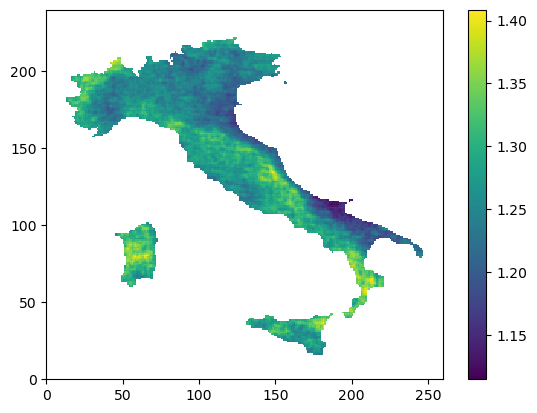

In [73]:
plt.pcolormesh(BETA_IM)
plt.colorbar()

In [54]:
products = ['IMERG', 'CMORPH', 'MSWEP', 'ERA5', 'GSMaP', 'CHIRPS']

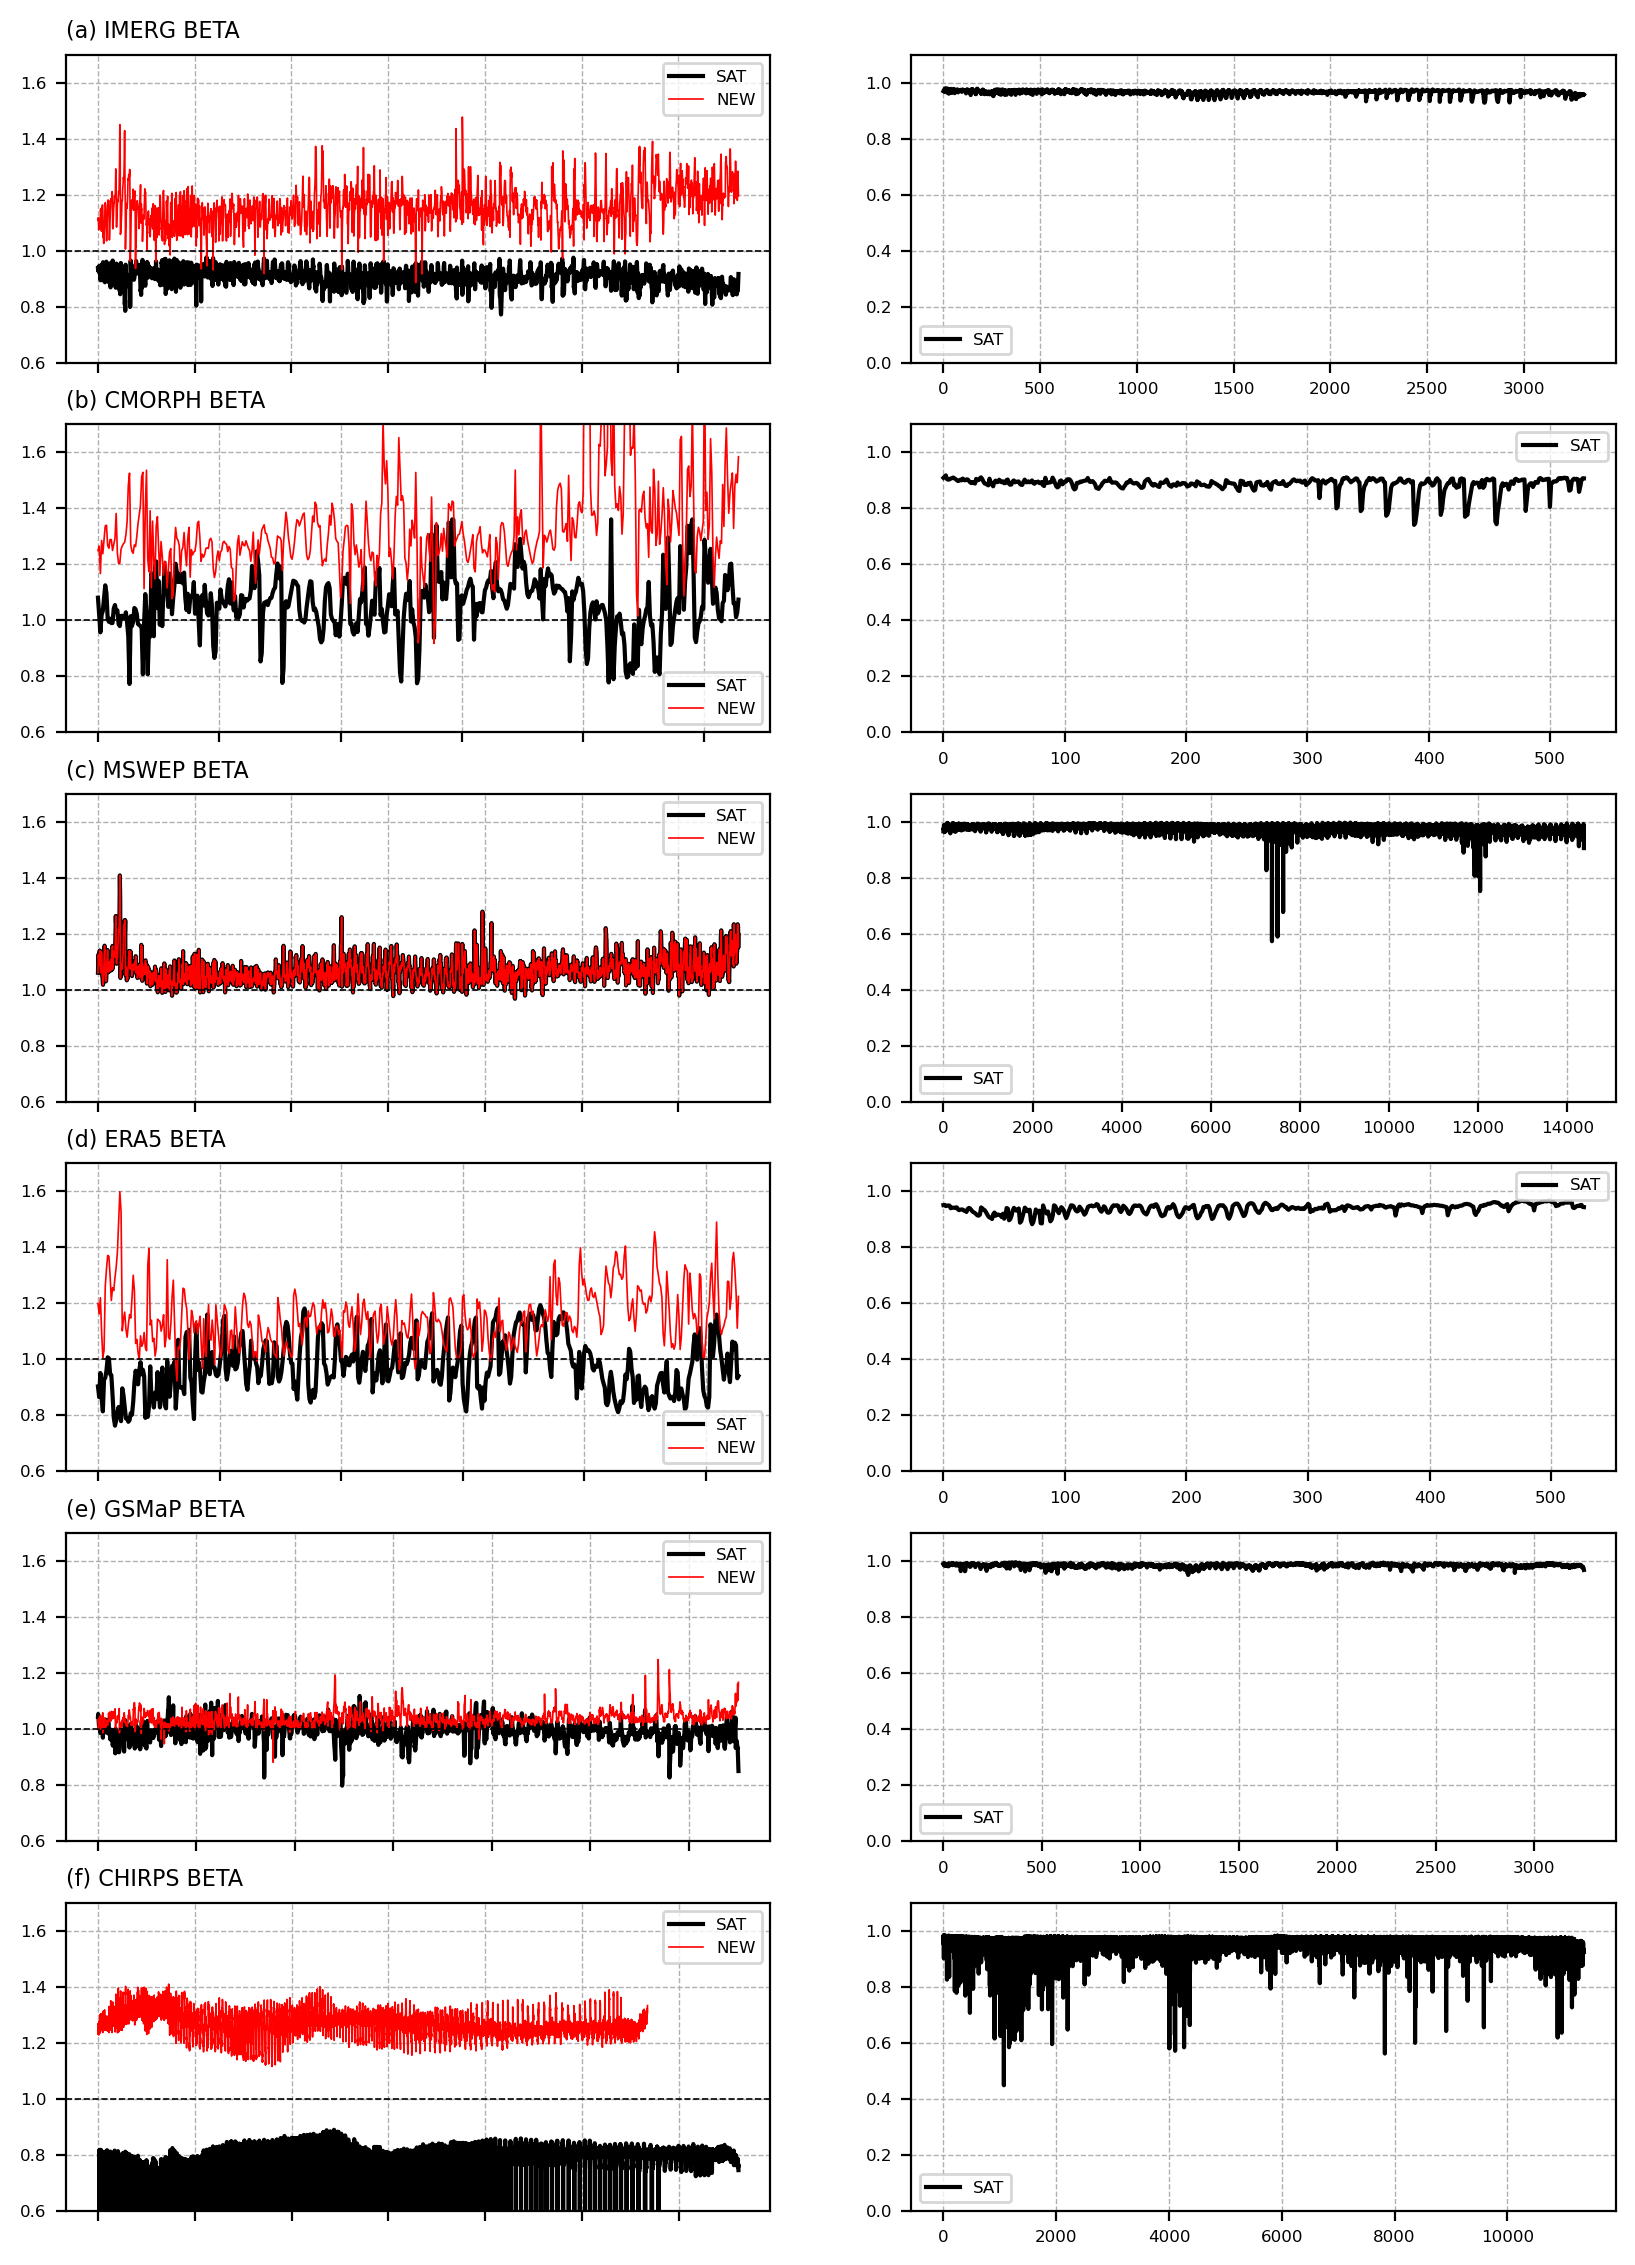

In [55]:

fig = plt.figure(figsize=(10, 14), dpi=200)
gs = gridspec.GridSpec(6, 2)

# =================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(BETA_IM[np.isnan(BETA_IM)==False],c='k',label='SAT')
ax1.plot(BETA_IM_NEW[np.isnan(BETA_IM_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(a) IMERG BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[0, 1])
plt.plot(GAMMA_IM[np.isnan(GAMMA_IM)==False],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)

# =================================================================
ax1 = plt.subplot(gs[1, 0])
ax1.plot(BETA_CM[np.isnan(BETA_CM)==False],c='k',label='SAT')
ax1.plot(BETA_CM_NEW[np.isnan(BETA_CM_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(b) CMORPH BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[1, 1])
plt.plot(GAMMA_CM[np.isnan(GAMMA_CM)==False],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)

# =================================================================
ax1 = plt.subplot(gs[2, 0])
ax1.plot(BETA_MS[np.isnan(BETA_MS)==False],c='k',label='SAT')
ax1.plot(BETA_MS_NEW[np.isnan(BETA_MS_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(c) MSWEP BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[2, 1])
plt.plot(GAMMA_MS[np.isnan(GAMMA_MS)==False],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)

# =================================================================
ax1 = plt.subplot(gs[3, 0])
ax1.plot(BETA_ER[np.isnan(BETA_ER)==False],c='k',label='SAT')
ax1.plot(BETA_ER_NEW[np.isnan(BETA_ER_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(d) ERA5 BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[3, 1])
plt.plot(GAMMA_ER[np.isnan(GAMMA_ER)==False],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)

# =================================================================
ax1 = plt.subplot(gs[4, 0])
ax1.plot(BETA_GS[np.isnan(BETA_GS)==False],c='k',label='SAT')
ax1.plot(BETA_GS_NEW[np.isnan(BETA_GS_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(e) GSMaP BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[4, 1])
plt.plot(GAMMA_GS[np.isnan(GAMMA_GS)==False],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)

# =================================================================
ax1 = plt.subplot(gs[5, 0])
ax1.plot(BETA_CH[np.isnan(BETA_CH)==False],c='k',label='SAT')
ax1.plot(BETA_CH_NEW[np.isnan(BETA_CH_NEW)==False],c='r',linewidth=0.6,label='NEW')
ax1.axhline(y=1, color='k', linestyle='--', linewidth=0.6)
ax1.set_ylim(0.6,1.7)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)
ax1.set_title('(f) CHIRPS BETA', loc='left', fontsize=8)
ax1.set_xticklabels([])

ax1 = plt.subplot(gs[5, 1])
plt.plot(GAMMA_CH[(np.isnan(GAMMA_CH)==False) & (GAMMA_CH!=0)],c='k',label='SAT')

ax1.set_ylim(0,1.1)
ax1.grid(linewidth=0.5,linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.legend(fontsize=6)